# **Step3. 속성 기반 감정 분류**

**미션 : 리뷰 안에 담긴 11가지 속성 감성 분석하기(Aspect-Based Sentiment Analysis)**
1) 목표 : 속성 기반 감성 분석을 통해, 리뷰 내용을 속성에 따라 긍, 부정
으로 분류하는 모델 생성
2) 절차① : “[ASPECT] 속성 [SEP] 문장”
    * 데이터 전처리 : 데이터셋 구성, 토크나이즈
    * 스페셜 토큰 추가 + 모델의 임베딩 층 resizing
    * 파인튜닝 및 모델 평가
3) 절차② : “Aspect : 문장”
    * 데이터 전처리 : 데이터셋 구성, 토크나이즈
    * 파인튜닝 및 모델 평가
4) 성능 비교 : “Aspect : 문장”
    * 모델 별 : klue/bert-base, klue/RoBERTa-base
    * 전처리 별 : Case①, Case②
    * Macro Recall, Macro Precision, Macro F1-Score 비교

## 1.환경준비

### (1) 라이브러리 설치 및 로딩

In [ ]:
# 한글폰트 설치
import matplotlib as mpl
import matplotlib.font_manager as fm

%config InlineBackend.figure_format = 'retina'
!apt -qq -y install fonts-nanum

font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fontprop = fm.FontProperties(fname=font_path)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import torch

from transformers import Trainer, TrainingArguments, EarlyStoppingCallback, AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset, Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import LabelEncoder

import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

### (2) 데이터 로딩
* data.csv 파일 로딩

In [ ]:
# 파일 업로드
from google.colab import files
uploaded = files.upload()

* 전제 데이터 중 10,000건만 샘플링
    * 학습 속도 고려

### (3) GPU 설정
* GPU 사용을 위한 설정

In [ ]:
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

## 2.방식① : [ASPECT] 속성 [SEP] 문장

* 두가지 모델에 대해서 튜닝을 시도해봅시다.
    * model_name1 = "klue/bert-base"
    * model_name2 = "klue/roberta-base"

### (1) 데이터 준비
* 데이터셋 분할 및 텐서 데이터셋 변환
* 토크나이징 함수 안에서,
    * "[ASPECT] 속성 [SEP] 문장" 형태로 수정
    * 토크나이징

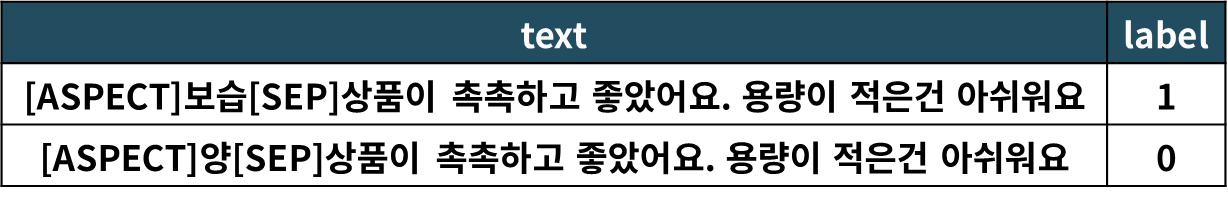

#### 1) 데이터셋 분할 및 텐서 데이터셋 변환

In [ ]:
aspects = ['보습', '기능', '밀착', '가격', '향', '편의성', '기타', '외형', '포장', '품질', '피부']

In [ ]:
# train, val 데이터 분할


In [ ]:
# df로 부터 텐서 데이터셋 만들기


#### 2) 토크나이징
* "[ASPECT] 속성 [SEP] 문장" 형태로 수정
* 다중 레이블 분류 문제에서 label은 float 타입이어야 함

* 토크나이저 준비 : 두 모델에 대한 토크나이저 로딩

* 사용자 정의 스페셜 토큰 등록하기

In [ ]:
# 사용자 정의 스페셜 토큰 목록


# 토크나이저에 추가



* 토크나이징을 포함한 함수 생성 및 적용

In [ ]:
# 모델1 전처리 함수



# 모델1 전처리 적용



# 모델2 전처리 함수



# 모델2 전처리 적용




### (2) Fine-Tuning

#### 1) 사전학습 모델 준비
* 모델 로드한 후
* 반드시 `모델.resize_token_embeddings(len(tokenizer))`

In [ ]:
# 모델1


In [ ]:
# 모델2


#### 2) 학습 설정

* TrainingArguments 설정
    * 두 모델에 공통으로 하나만 설정해도 됨

* Trainer 설정
    * 두 모델 각각 설정

In [ ]:
# Trainer1 설정



# Trainer2 설정



#### 3) 학습

#### 4) 모델 검증평가

* 예측

* 평가 : model1

* 평가 : model2

## 3.방식② : 속성 : 문장

* 두가지 모델에 대해서 튜닝을 시도해봅시다.
    * model_name1 = "klue/bert-base"
    * model_name2 = "klue/roberta-base"

### (1) 데이터 준비
* 데이터셋 분할 및 텐서 데이터셋 변환
* 토크나이징 함수 안에서,
    * "ASPECT : 문장" 형태로 수정
    * 토크나이징

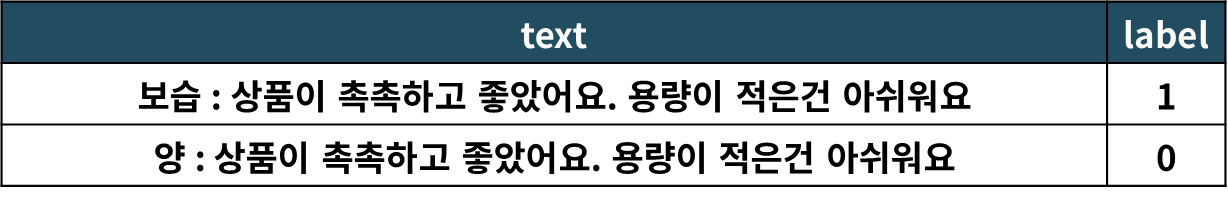

#### 1) 데이터셋 분할 및 텐서 데이터셋 변환

In [ ]:
aspects = ['보습', '기능', '밀착', '가격', '향', '편의성', '기타', '외형', '포장', '품질', '피부']

In [ ]:
# train, val 데이터 분할


In [ ]:
# df로 부터 텐서 데이터셋 만들기


#### 2) 토크나이징
* "ASPECT : 문장" 형태로 수정
* 다중 레이블 분류 문제에서 label은 float 타입이어야 함

* 토크나이저 준비 : 두 모델에 대한 토크나이저 로딩

* 토크나이징을 포함한 함수 생성 및 적용

In [ ]:
# 모델1 전처리 함수


# 모델1 전처리 적용


# 모델2 전처리 함수


# 모델2 전처리 적용



### (2) Fine-Tuning

#### 1) 사전학습 모델 준비

#### 2) 학습 설정

* TrainingArguments 설정
    * 두 모델에 공통으로 하나만 설정해도 됨

* Trainer 설정
    * 두 모델 각각 설정

#### 3) 학습

#### 4) 모델 검증평가

* 예측

* 평가